In [1]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns

# Custom modules
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
from spk_feat_cluster_comp_analysis  import *

In [2]:
cluster_pickle_dir = "/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/cluster_pickles/"

### Step 1: Create dataframe with all experiment metadata and clustering results

In [3]:
#create df for all experiments 
df_master = compile_experiment_results(cluster_pickle_dir)


In [4]:
df_master

,cell_id,patch_type,current_type,cell_type,cortical_depth,dark_neuron,clear_EAP_waveform,spike_feature,num_clusters,cluster,nRMSE,cos_sim
0,c1,Juxta,IC,PC,843.9,False,False,peak_amp,3,Low-High,0.097350,0.990636
1,c1,Juxta,IC,PC,843.9,False,False,peak_sharpness,3,Low-High,0.089557,0.994296
2,c1,Juxta,IC,PC,843.9,False,False,exp_lambda,3,Low-High,0.057307,0.991058
3,c1,Juxta,IC,PC,843.9,False,False,log_isi,3,Low-Mid,0.042693,0.998962
4,c1,Juxta,IC,PC,843.9,False,False,log_isi,3,Low-High,0.039721,0.999174
...,...,...,...,...,...,...,...,...,...,...,...,...
122,c45,Juxta,VC,PC,1137.0,False,True,exp_lambda,3,Low-Mid,0.098120,0.906886
123,c45,Juxta,VC,PC,1137.0,False,True,exp_lambda,3,Low-High,0.057813,0.970601
124,c45,Juxta,VC,PC,1137.0,False,True,exp_lambda,3,Mid-High,0.044018,0.980513
125,c46,Juxta,VC,PC,1039.7,False,True,exp_lambda,2,Low-High,0.008720,0.999815


In [5]:
#sort by cell id
# Create a numeric column for sorting (c1, c2, c10, etc.)
df_master['sort_idx'] = df_master['cell_id'].str.extract('(\d+)').astype(int)

# Sort by the numeric ID, then by feature name
df_master = df_master.sort_values(by=['sort_idx', 'spike_feature']).drop(columns=['sort_idx'])



### Step 2: Generate table figure from dataframe 


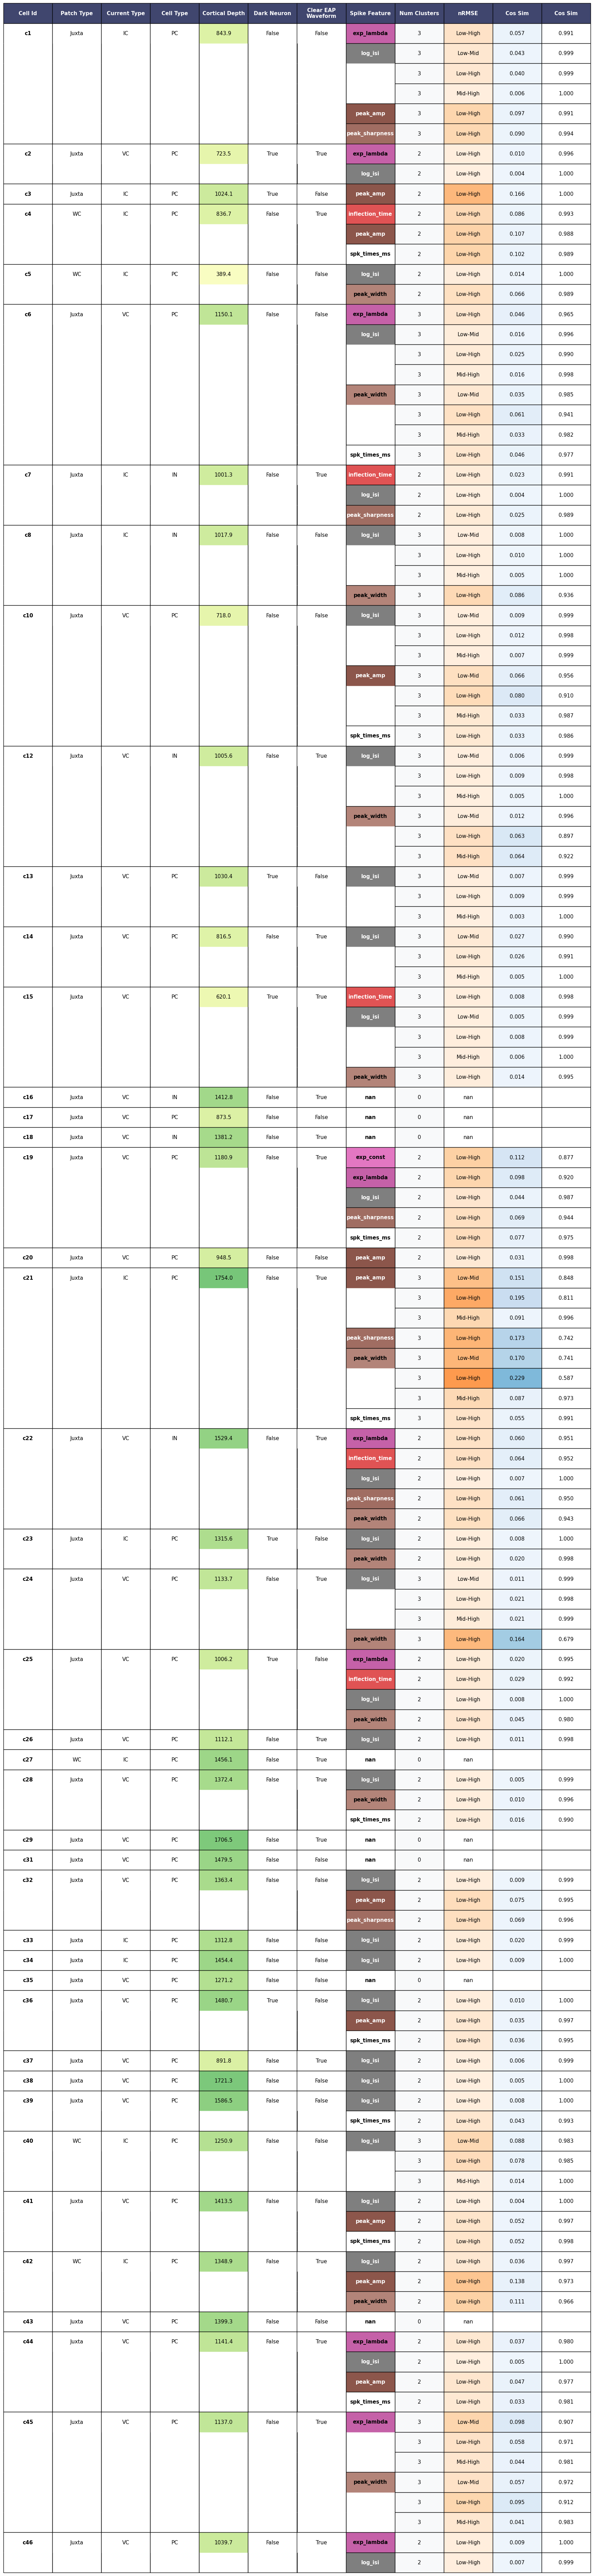

In [6]:

gen_table_fig(df_master)


### Step 3: Patterns for clustering/metadata

#### A) Do metadata features correlate with clustering waveform quantification (nRMSE, cos sim, number of clusters)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


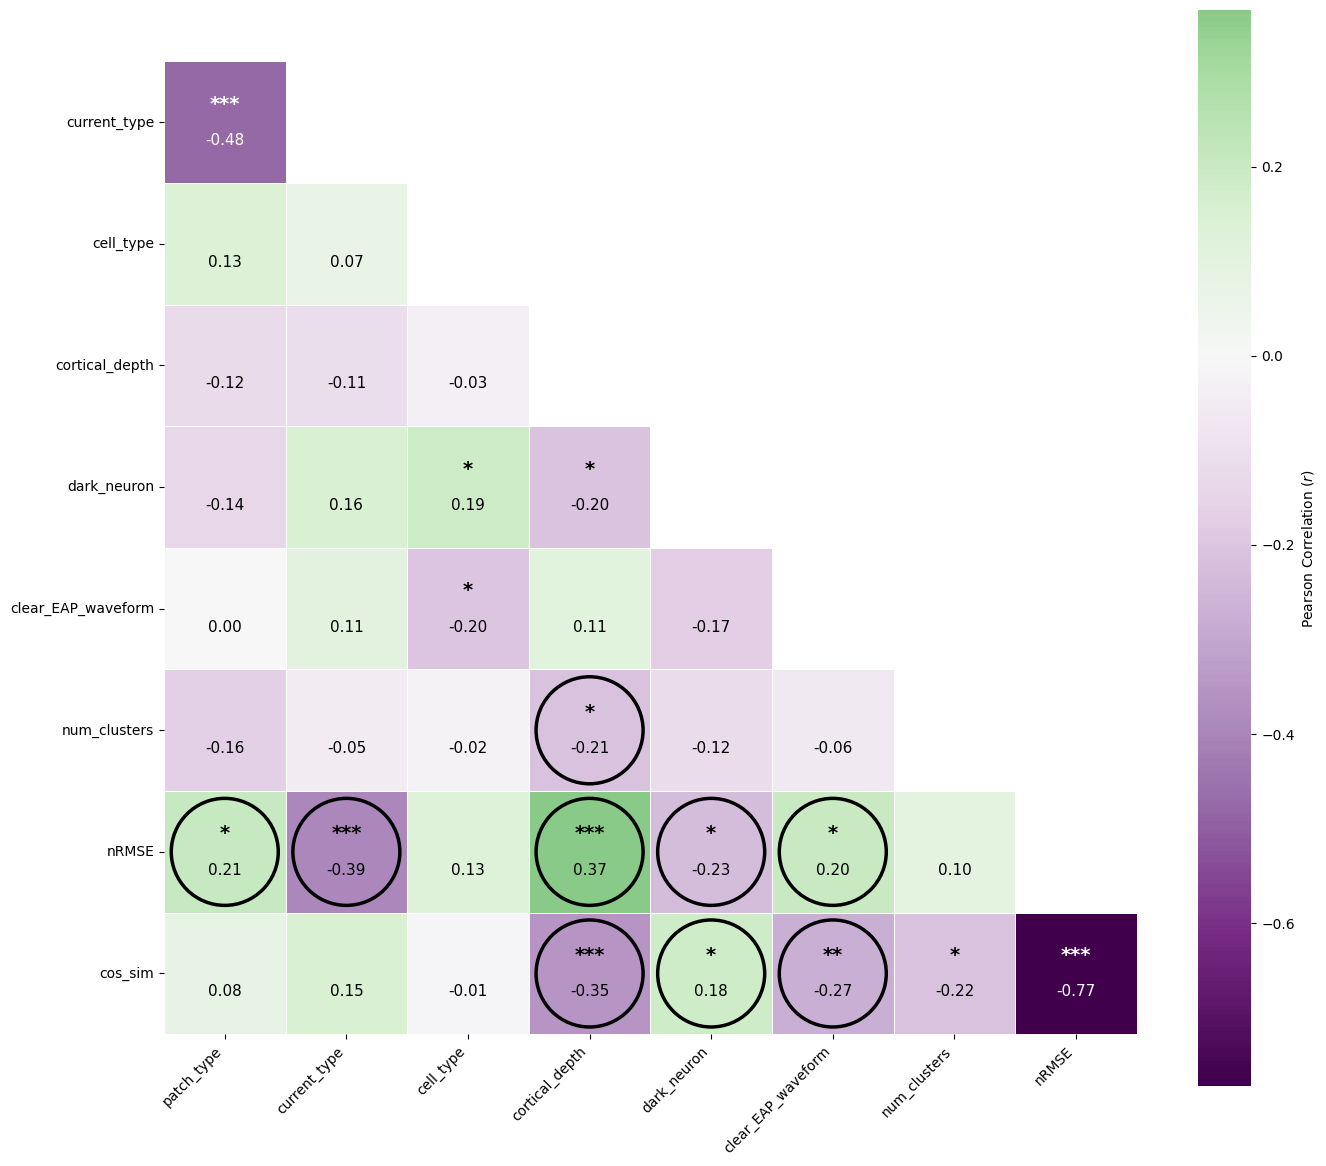

,Metadata,Feature,Pearson $r$,p-value,Significance
0,current_type,nRMSE,-0.394,9.32e-06,***
1,cortical_depth,nRMSE,0.366,4.28e-05,***
2,cortical_depth,cos_sim,-0.352,8.78e-05,***
3,clear_EAP_waveform,cos_sim,-0.273,2.66e-03,**
4,dark_neuron,nRMSE,-0.231,1.13e-02,*
5,cortical_depth,num_clusters,-0.215,1.91e-02,*
6,patch_type,nRMSE,0.209,2.25e-02,*
7,clear_EAP_waveform,nRMSE,0.202,2.75e-02,*
8,dark_neuron,cos_sim,0.181,4.86e-02,*


In [7]:
sig_meta_clust_feats = analyze_cross_correlations(df_master)
sig_meta_clust_feats

#### Explore the pairs that are correlated

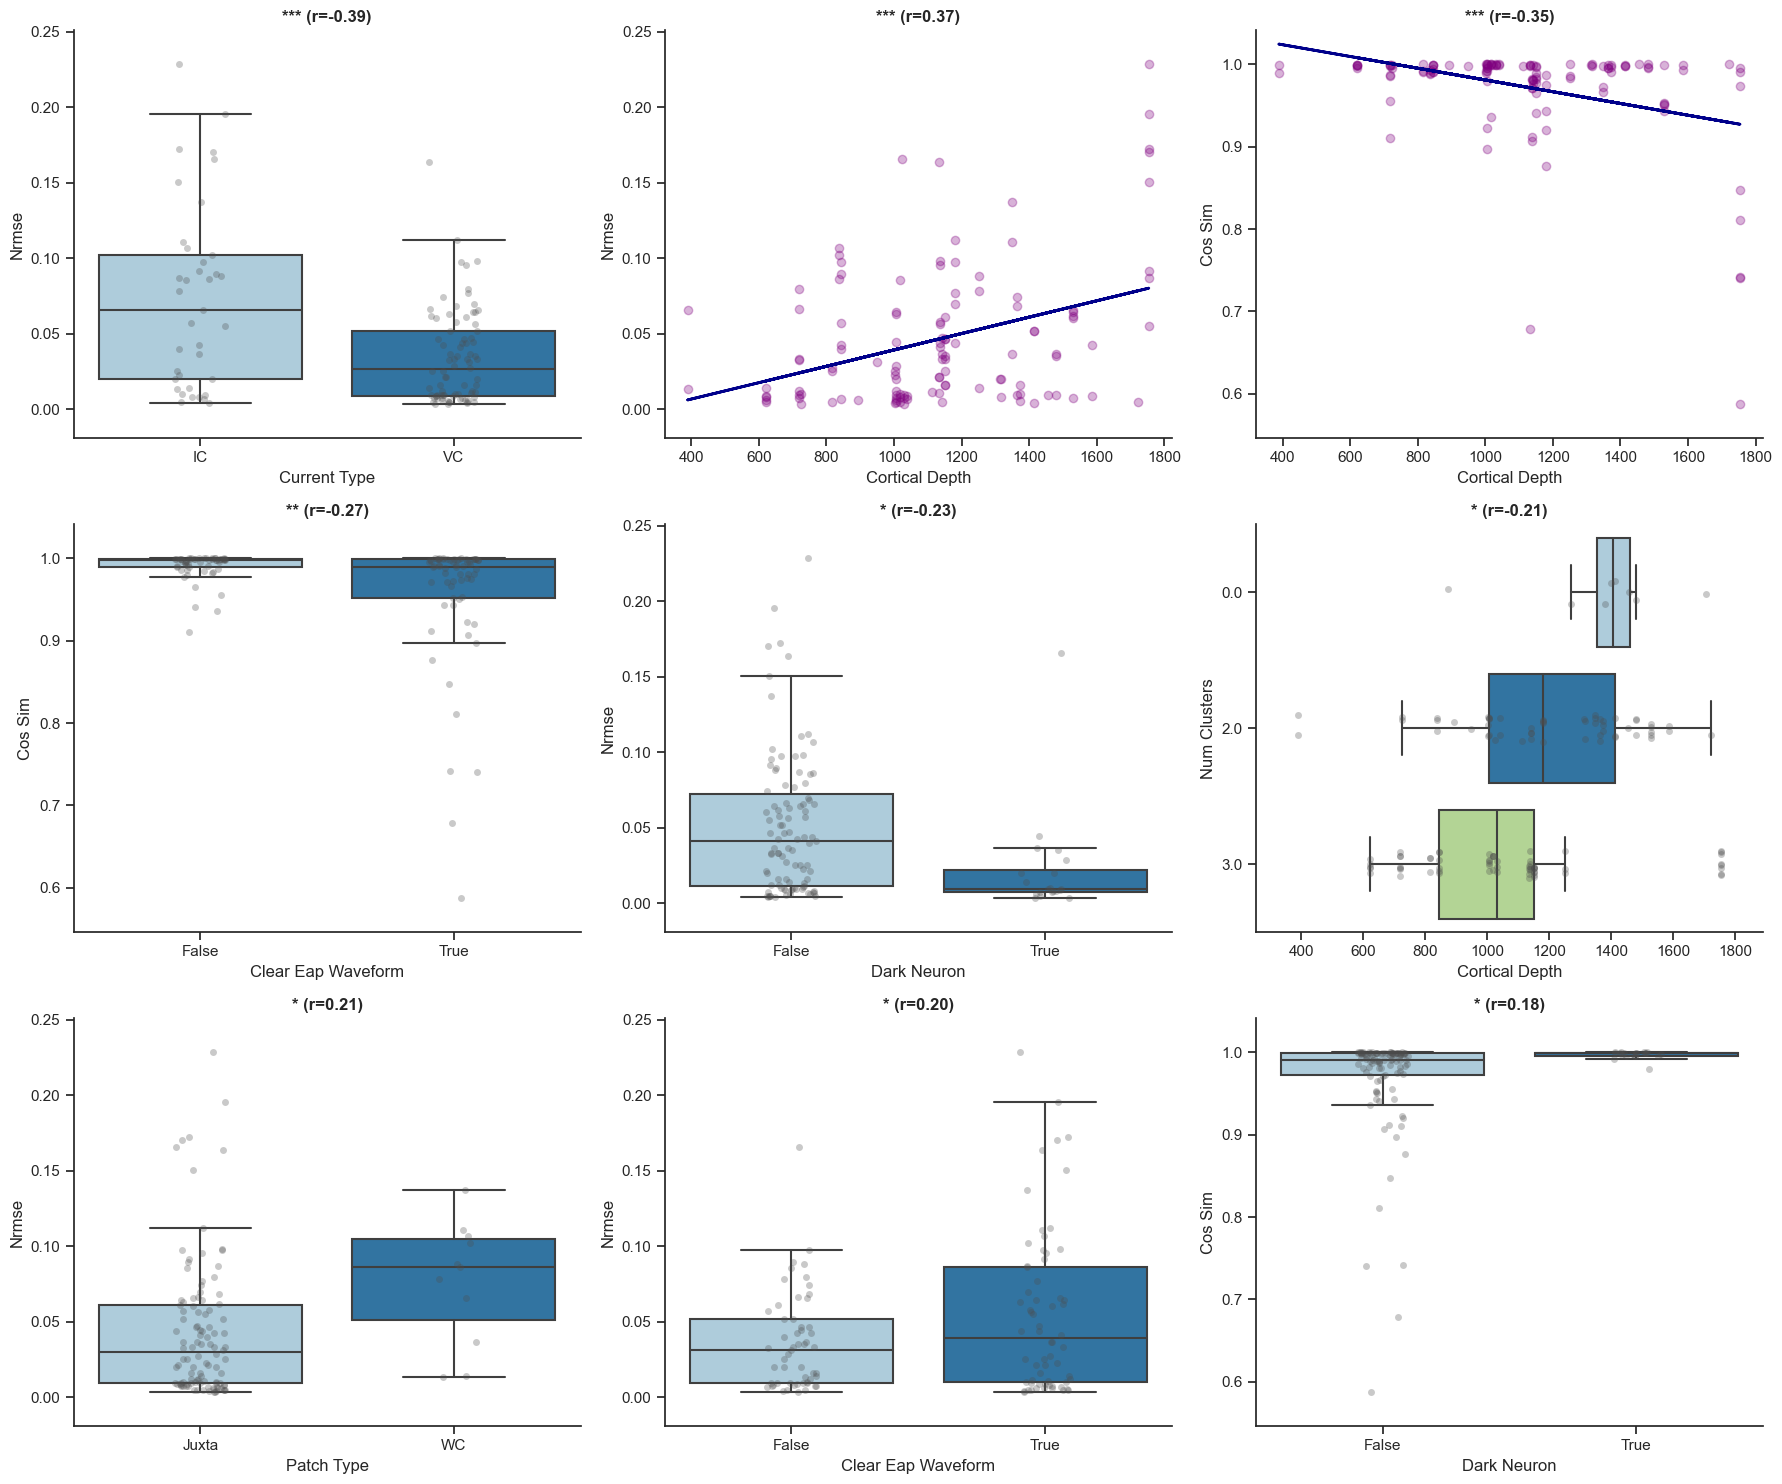

In [8]:
plot_sig_feat_pairs(df_master, sig_meta_clust_feats)



#### B) Study patterns in the spike features that cluster

##### Analyze spike features and cluster features

In [9]:
#Aggregate cluster metrics and prevalence by spike feature
spk_feat_prevalence = quantify_spk_feature_prevalence(df_master)


In [10]:
spk_feat_prevalence

,spike_feature,n_cells_with_feature,prevalence_pct,num_clusters,cos_sim,nRMSE
3,log_isi,30,69.767442,2.600000,0.997804,0.015388
6,peak_width,13,30.232558,2.714286,0.922525,0.072863
4,peak_amp,11,25.581395,2.466667,0.961525,0.090968
7,spk_times_ms,10,23.255814,2.300000,0.987462,0.049424
1,exp_lambda,9,20.930233,2.454545,0.968766,0.048851
5,peak_sharpness,6,13.953488,2.333333,0.935970,0.081153
2,inflection_time,5,11.627907,2.200000,0.985291,0.042024
0,exp_const,1,2.325581,2.000000,0.876566,0.112272


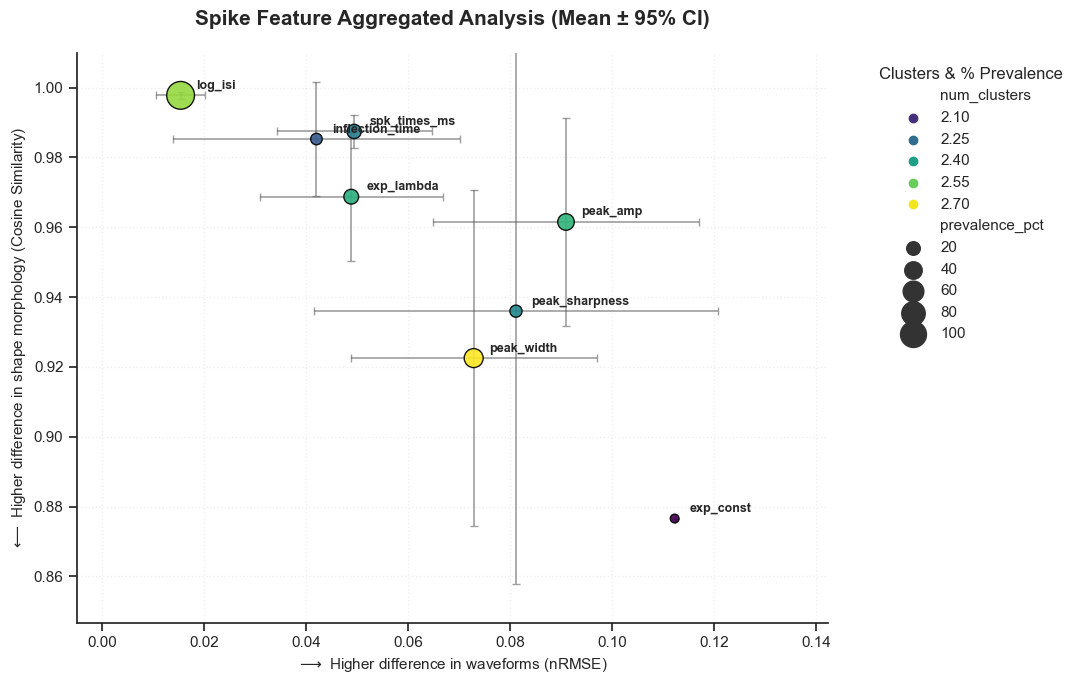

In [11]:
plot_aggregated_spike_feat(df_master)


##### Analyze spike features in relation to metadata

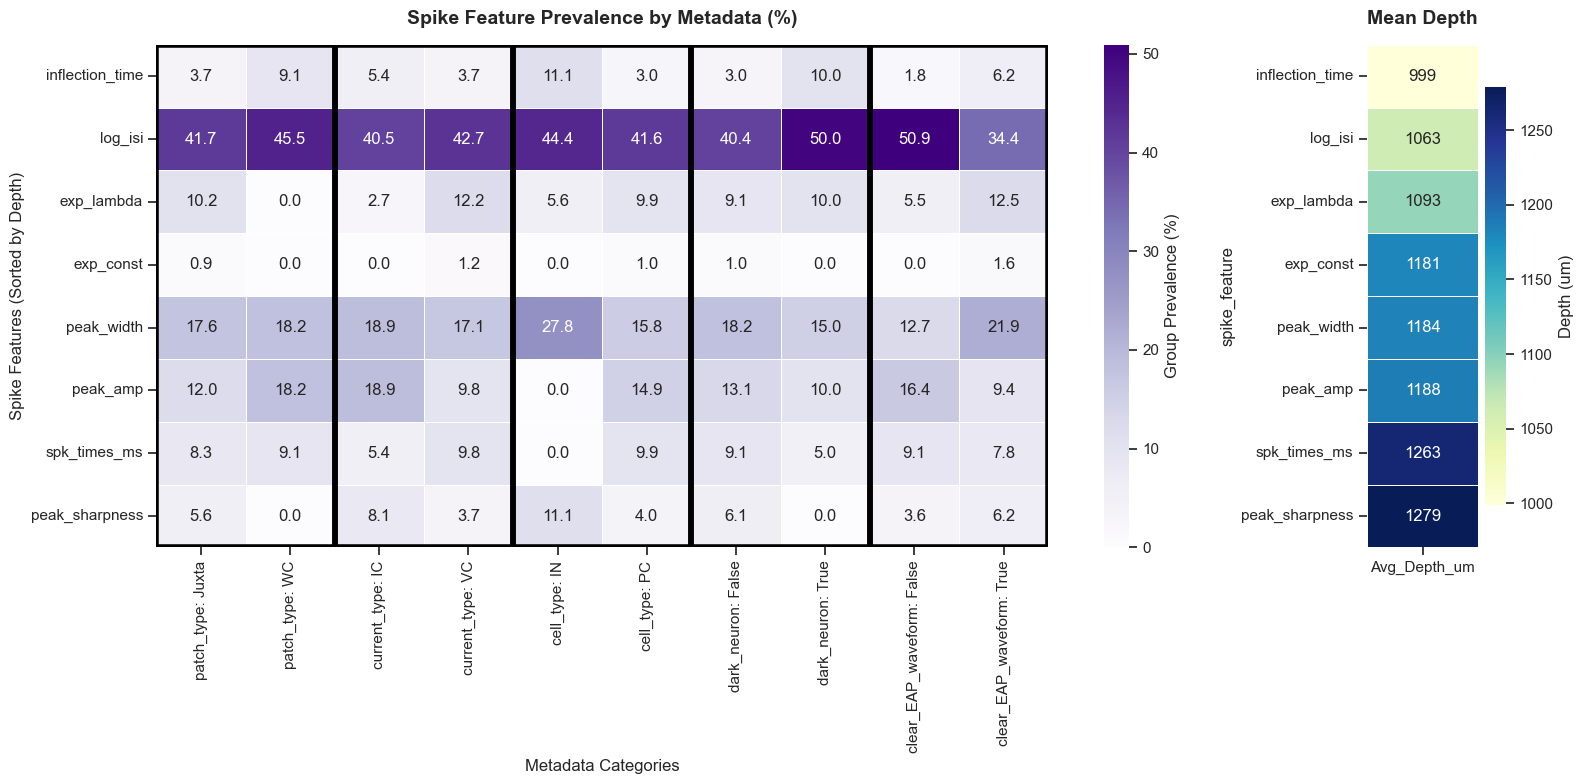

In [17]:
plot_meta_spk_feature_dependency(df_master)

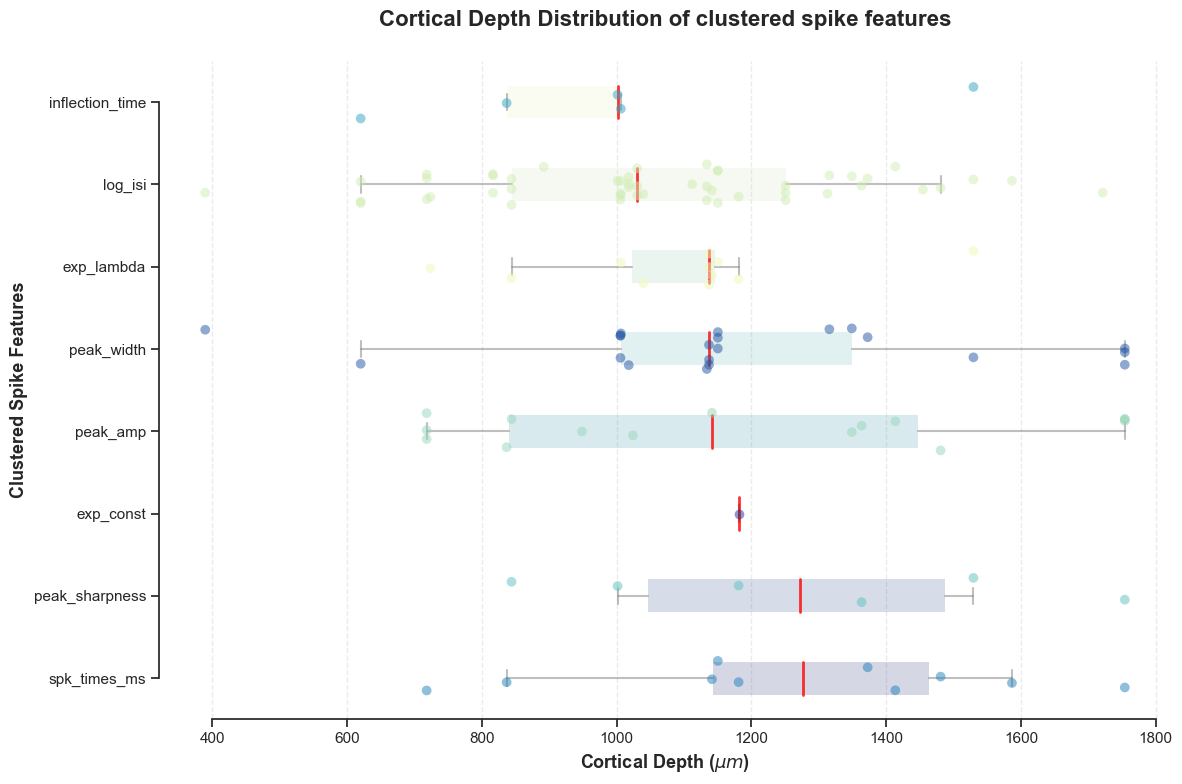

In [13]:
plot_feature_depth_distribution(df_master)

#### C) What are the experiments with the biggest difference in waveform (nRMSE) and waveform abs shape (cos sim)

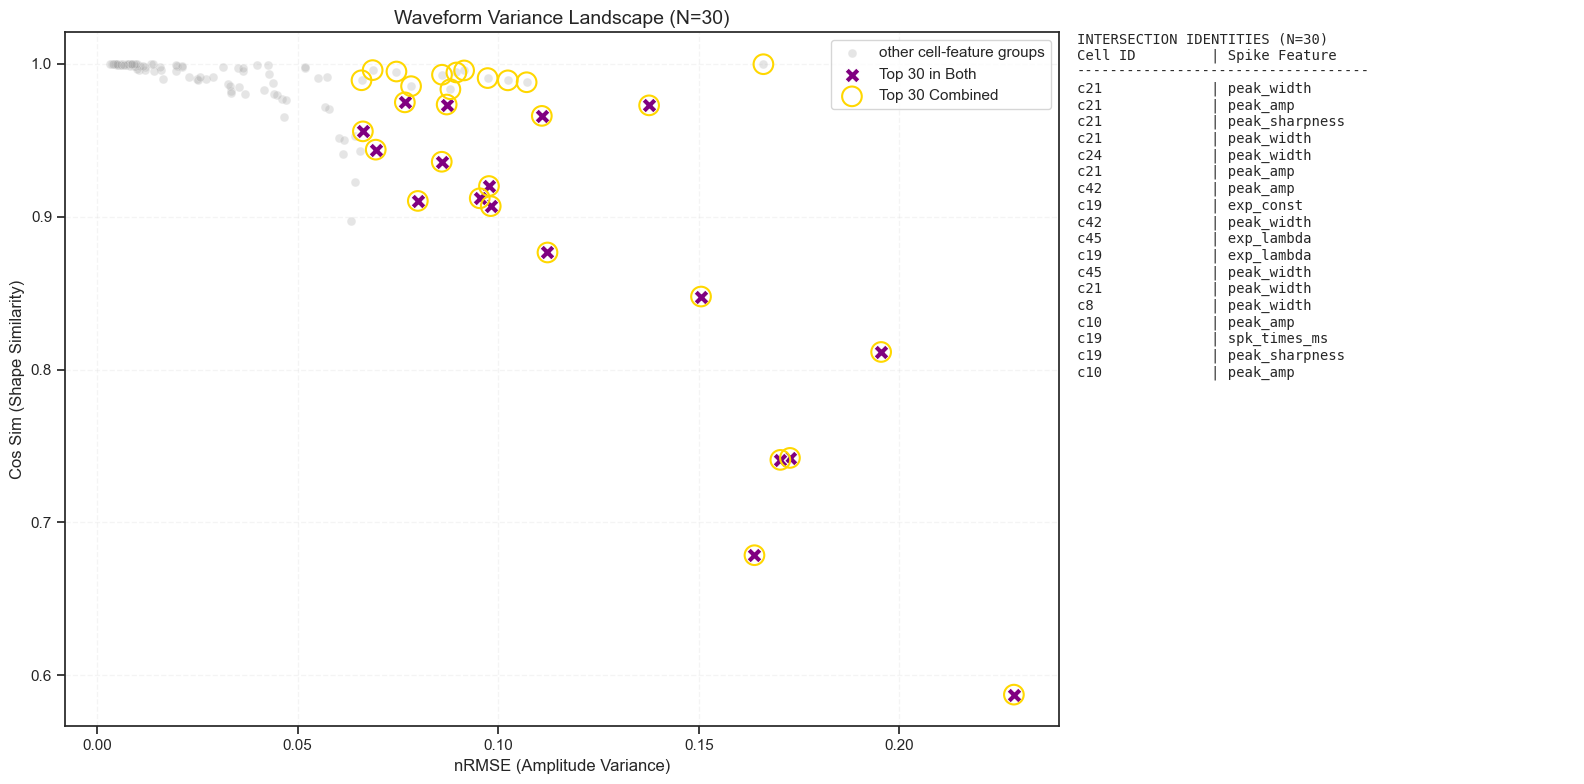

In [14]:
top_var_df = analyze_waveform_variance(df_master, N=30)

In [15]:
top_var_df 

,cell_id,patch_type,current_type,cell_type,cortical_depth,dark_neuron,clear_EAP_waveform,spike_feature,num_clusters,cluster,nRMSE,cos_sim
66,c21,Juxta,IC,PC,1754.0,False,True,peak_width,3,Low-High,0.228570,0.587372
63,c21,Juxta,IC,PC,1754.0,False,True,peak_amp,3,Low-High,0.195470,0.811497
68,c21,Juxta,IC,PC,1754.0,False,True,peak_sharpness,3,Low-High,0.172731,0.742211
65,c21,Juxta,IC,PC,1754.0,False,True,peak_width,3,Low-Mid,0.170338,0.740929
77,c24,Juxta,VC,PC,1133.7,False,True,peak_width,3,Low-High,0.163883,0.678563
62,c21,Juxta,IC,PC,1754.0,False,True,peak_amp,3,Low-Mid,0.150555,0.847755
111,c42,WC,IC,PC,1348.9,False,True,peak_amp,2,Low-High,0.137614,0.972798
58,c19,Juxta,VC,PC,1180.9,False,True,exp_const,2,Low-High,0.112272,0.876566
112,c42,WC,IC,PC,1348.9,False,True,peak_width,2,Low-High,0.110860,0.965912
122,c45,Juxta,VC,PC,1137.0,False,True,exp_lambda,3,Low-Mid,0.098120,0.906886
